In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import ClassicalMDS
from sklearn.manifold import MDS
from sklearn.manifold import Isomap
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import locally_linear_embedding
from sklearn.manifold import SpectralEmbedding
from sklearn.manifold import TSNE
import seaborn as sns

In [2]:
# Load the MNIST data
# (available from https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz)  
with np.load("../../../data/mnist.npz") as f:
    Xtrain, ytrain = f['x_train'], f['y_train']

In [3]:
# vectorize images to matrices and subsample every 50th data point to make this run faster
# normalize gray scale values to [0,1]
Xtrain0 = Xtrain.reshape(60000, -1)
X = Xtrain0[::50, :]/255.0
y = ytrain[::50]
n, d = np.shape(X)

In [4]:
valuesy, countsy = np.unique(y, return_counts=True)
countsy/n

array([0.08333333, 0.10416667, 0.09583333, 0.10833333, 0.09833333,
       0.0925    , 0.0975    , 0.12416667, 0.0975    , 0.09833333])

In [5]:
# Method 1: Classical Scaling
cmds = ClassicalMDS(n_components=2)
X_emb = cmds.fit_transform(X)
X_emb.shape

(1200, 2)

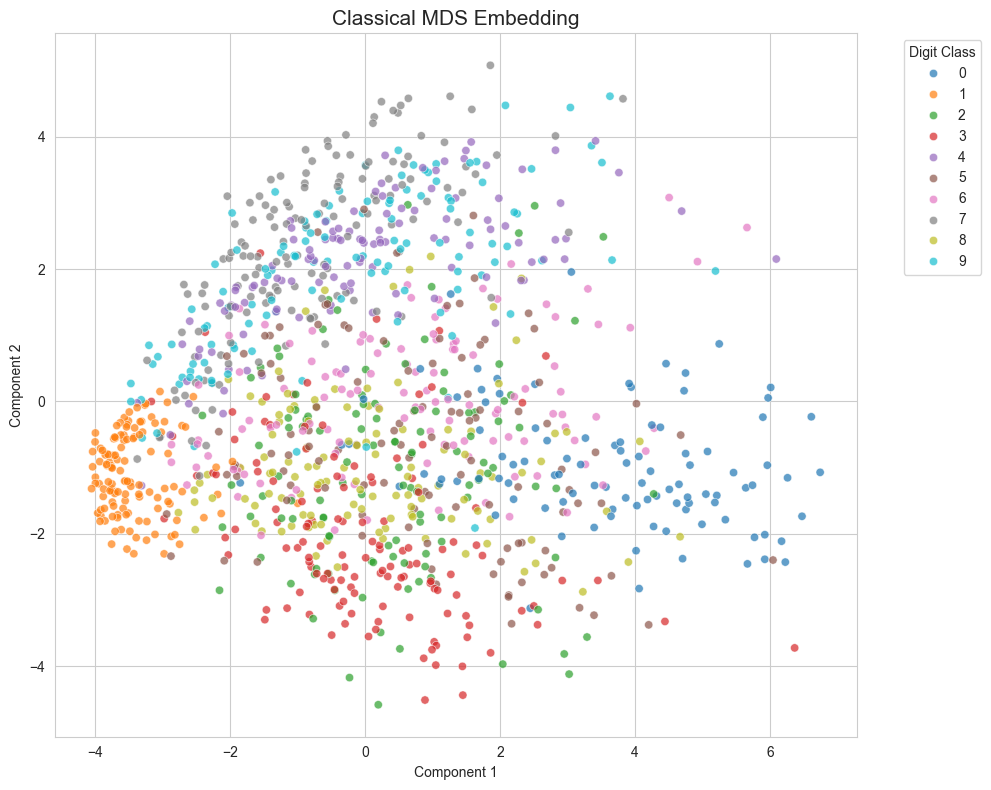

In [27]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    x=X_emb[:, 0], 
    y=X_emb[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7
)

plt.title("Classical MDS Embedding", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [34]:
# we can obtain an equivalent result using the pre-computed squared Euclidean distances 
sq_norms = np.sum(X**2, 1, keepdims=True) 
D2 =  sq_norms  @ np.ones([1,n]) + np.ones([n,1]) @ sq_norms.T -2 * (X @ X.T)
D2 = D2 - np.min(D2)
cmds2 = ClassicalMDS(n_components=2, metric = 'precomputed')
X_emb2 = cmds2.fit_transform(D2)
X_emb2.shape

(1200, 2)

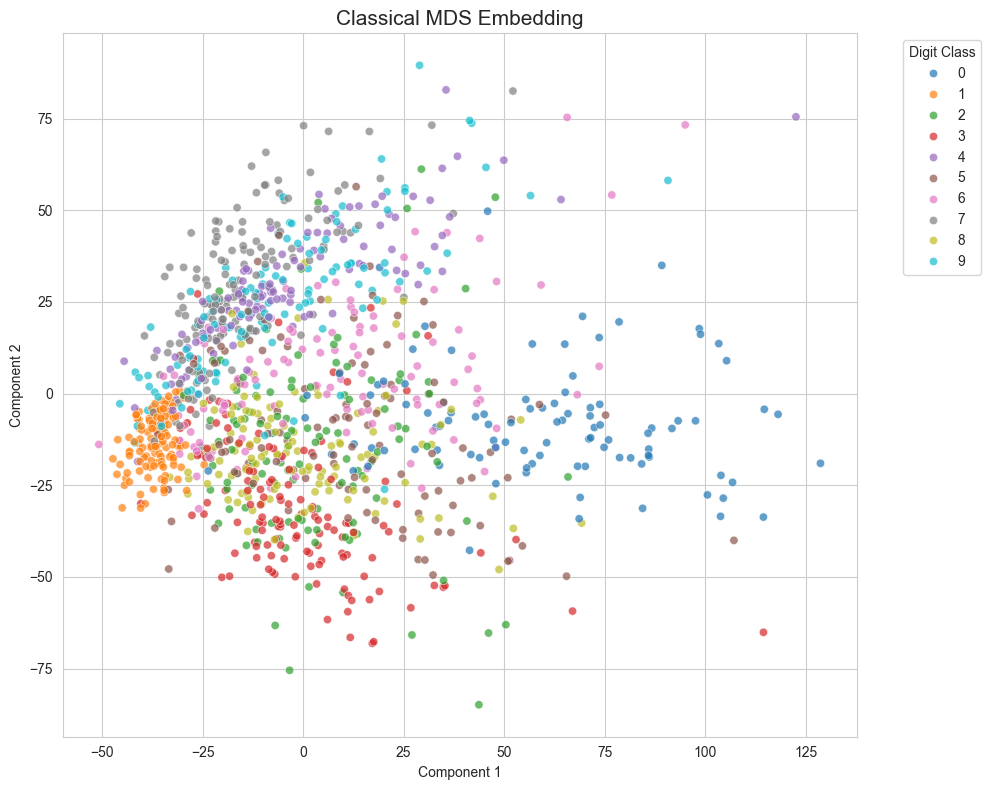

In [35]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    x=X_emb2[:, 0], 
    y=X_emb2[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7
)

plt.title("Classical MDS Embedding", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [38]:
# Method 2: Metric Scaling -- Sammon mapping 
metricmds = MDS(n_components=2, init="classical_mds", normalized_stress=True)
X_emb3 = metricmds.fit_transform(X)

/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(


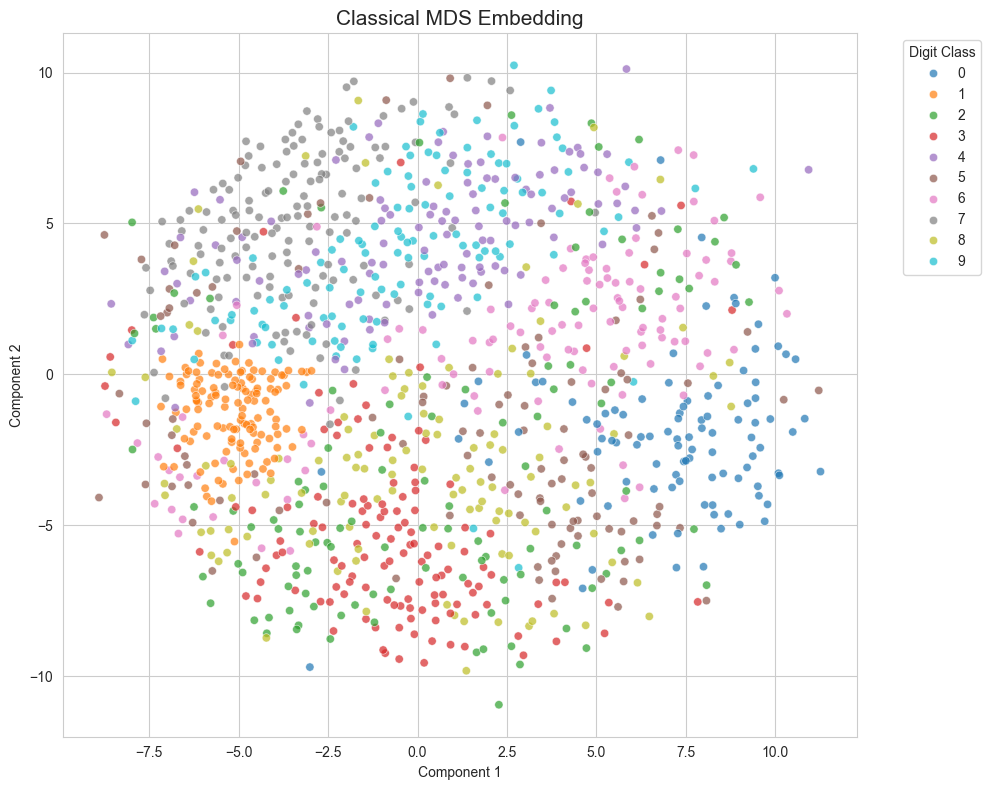

In [39]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    x=X_emb3[:, 0], 
    y=X_emb3[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7
)

plt.title("MDS Embedding", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
# Method 3: ISOMAP
iso = Isomap(n_components=2, n_neighbors = 10)
X_emb4 = iso.fit_transform(X)

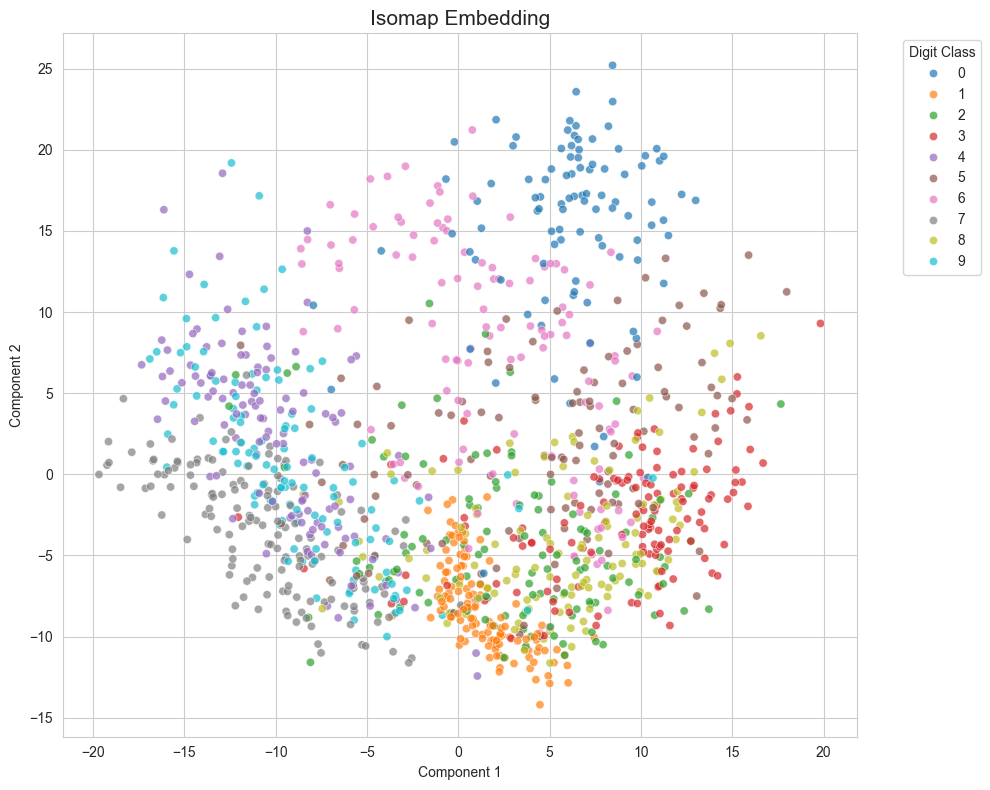

In [46]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    x=X_emb4[:, 0], 
    y=X_emb4[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7
)

plt.title("Isomap Embedding", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
### Method 4: Laplacian Eigenmap

# compute adjacency matrix of Gaussian kernel
sigma = 0.5 * np.median((np.sqrt(D2.flatten())))
A = np.exp(-D2 / sigma**2)
lap_eig = SpectralEmbedding(affinity = 'precomputed', n_components=10, random_state=42)
X_emb5 = lap_eig.fit_transform(A) # this returns an embedding of dimension 10

Text(0.5, 1.0, 'Dimension 2 vs 3')

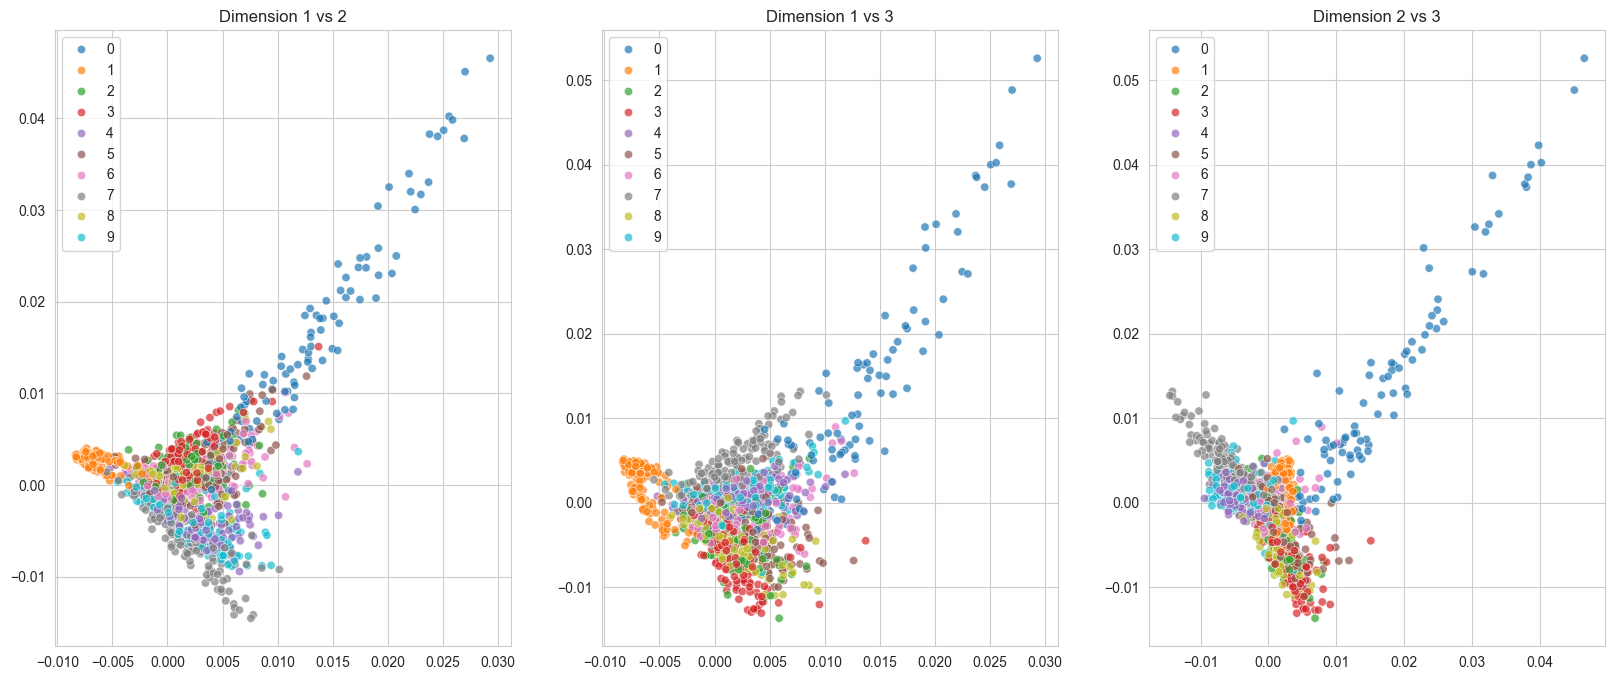

In [81]:
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

sns.set_style("whitegrid")

axs[0] = sns.scatterplot(
    x=X_emb5[:, 0], 
    y=X_emb5[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[0])

axs[0].set_title("Lap.Eigenmap: Dimension 1 vs 2")

axs[1] = sns.scatterplot(
    x=X_emb5[:, 0], 
    y=X_emb5[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[1]
)

axs[1].set_title("Lap.Eigenmap: Dimension 1 vs 3")

axs[2] = sns.scatterplot(
    x=X_emb5[:, 1], 
    y=X_emb5[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[2]
)

axs[2].set_title("Lap.Eigenmap: Dimension 2 vs 3")

In [85]:
### Method 5: t-SNE
tsne = TSNE(n_components=2, random_state = 1)
X_emb6 = tsne.fit_transform(X)

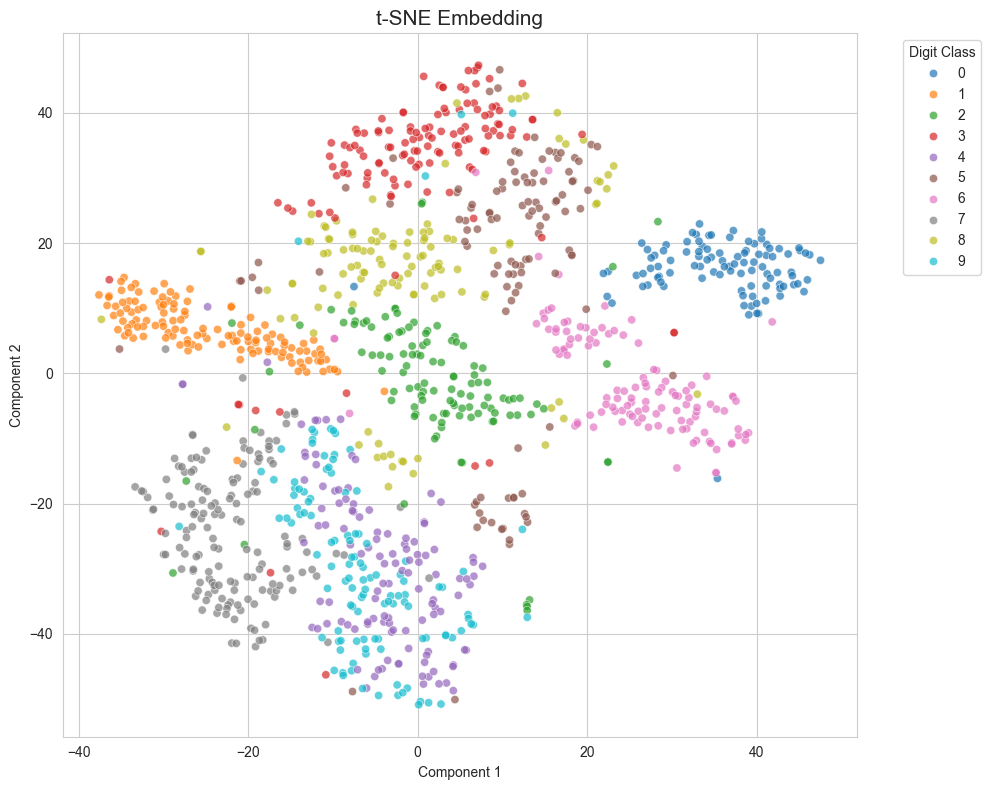

In [86]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    x=X_emb6[:, 0], 
    y=X_emb6[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7
)

plt.title("t-SNE Embedding", fontsize=15)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Digit Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [89]:
### Method 6: Locally Linear Embedding
lle = LocallyLinearEmbedding(n_components=10, n_neighbors = 10, random_state = 1)
X_emb7 = lle.fit_transform(X)

Text(0.5, 1.0, 'Dimension 2 vs 3')

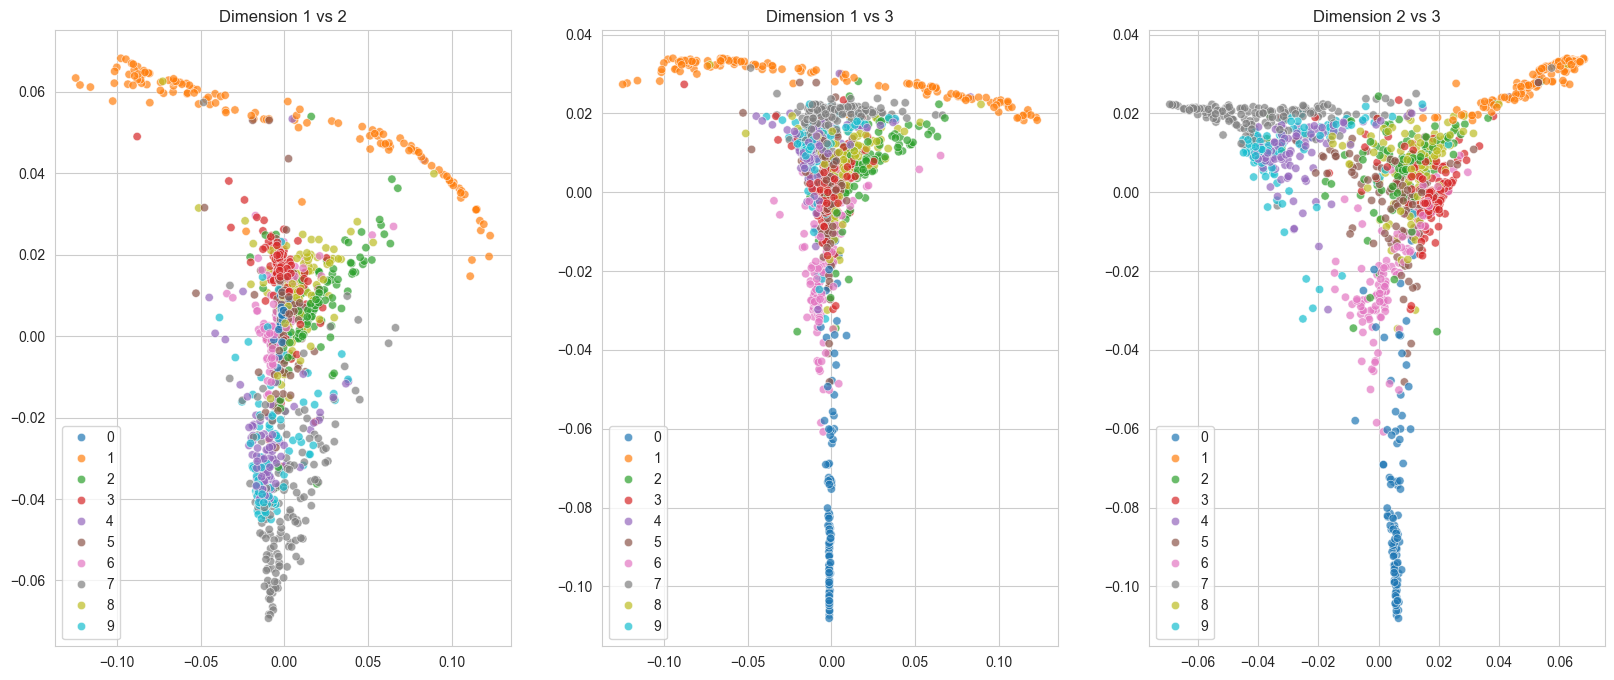

In [91]:
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

sns.set_style("whitegrid")

axs[0] = sns.scatterplot(
    x=X_emb7[:, 0], 
    y=X_emb7[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[0])

axs[0].set_title("LLE: Dimension 1 vs 2")

axs[1] = sns.scatterplot(
    x=X_emb7[:, 0], 
    y=X_emb7[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[1]
)

axs[1].set_title("LLE: Dimension 1 vs 3")

axs[2] = sns.scatterplot(
    x=X_emb7[:, 1], 
    y=X_emb7[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[2]
)

axs[2].set_title("LLE: Dimension 2 vs 3")

In [116]:
### Method 7: Hessian Eigenmaps
X_emb8,_ = locally_linear_embedding(X, n_components=10, method = 'hessian', n_neighbors = 70, random_state = 5)

# NOTE: this method has lower on bound on the number of neighbors that need to be chosen that scales quadratically with 
# the embedding dimension (n_components). This makes the method somewhat less 'localized'. 

Text(0.5, 1.0, 'HessEigenmap: Dimension 2 vs 3')

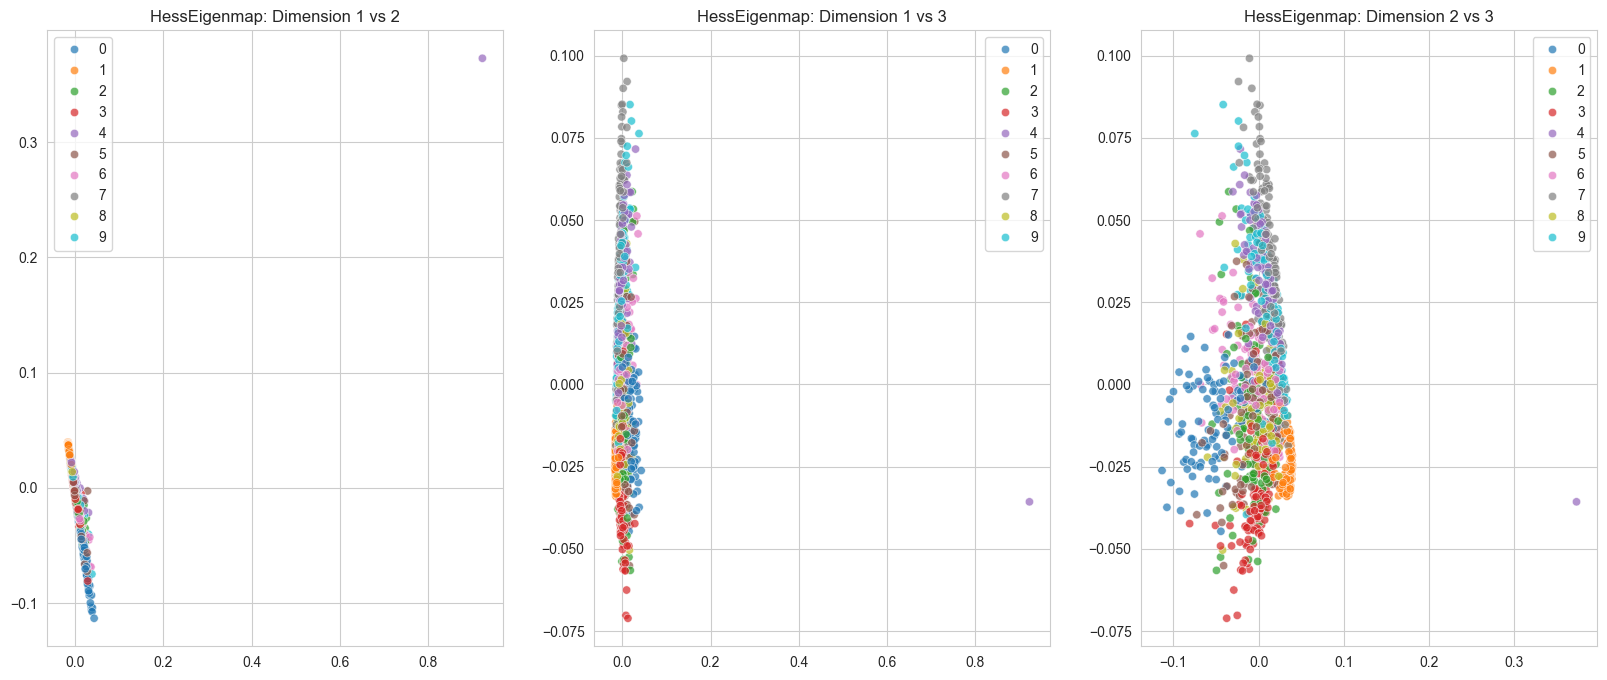

In [118]:
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

sns.set_style("whitegrid")

axs[0] = sns.scatterplot(
    x=X_emb8[:, 0], 
    y=X_emb8[:, 1], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[0])

axs[0].set_title("HessEigenmap: Dimension 1 vs 2")

axs[1] = sns.scatterplot(
    x=X_emb8[:, 0], 
    y=X_emb8[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[1]
)

axs[1].set_title("HessEigenmap: Dimension 1 vs 3")

axs[2] = sns.scatterplot(
    x=X_emb8[:, 1], 
    y=X_emb8[:, 2], 
    hue=y, 
    palette="tab10", 
    legend="full", 
    alpha=0.7, ax=axs[2]
)

axs[2].set_title("HessEigenmap: Dimension 2 vs 3")